# Import Necessary Libraries & Setup

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)


In [94]:
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Data Loading and Exploration

In [95]:
# Load dataset
df = pd.read_csv('customer_churn_data.csv')

DATASET OVERVIEW

In [96]:
# Display basic information

print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()


Shape: 5880 rows, 21 columns

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,No,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,Yes,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


DATA TYPES AND MISSING VALUES

In [97]:
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})
info_df

,Data Type,Missing Values,Missing %,Unique Values
customerID,object,0,0.0,5880
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,72
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


STATISTICAL SUMMARY - NUMERICAL FEATURES

In [98]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.500680,36.549150,70.157779,2566.813165
std,0.500042,20.909674,28.804615,1910.017743
min,0.000000,1.000000,20.000000,20.030000
25%,0.000000,18.000000,45.717500,1020.217500
50%,1.000000,37.000000,70.155000,2136.445000
75%,1.000000,55.000000,95.457500,3767.665000
max,1.000000,72.000000,119.990000,8589.600000


TARGET VARIABLE DISTRIBUTION (Churn)

In [99]:
churn_dist = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 10

In [100]:
print(f"\nChurn Distribution:")
print(f"  No Churn:  {churn_dist['No']} ({churn_pct['No']:.2f}%)")
print(f"  Churn:     {churn_dist['Yes']} ({churn_pct['Yes']:.2f}%)")


Churn Distribution:
  No Churn:  2982 (5.07%)
  Churn:     2898 (4.93%)


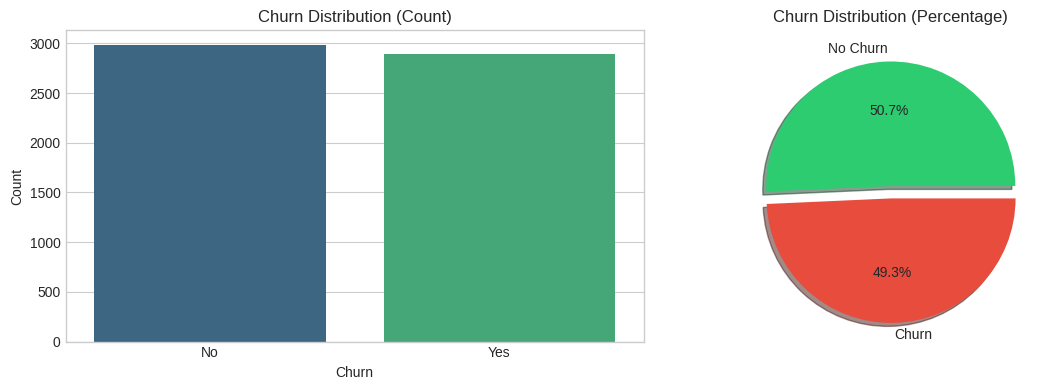

In [101]:
# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='Churn', palette='viridis', ax=ax[0])
ax[0].set_title('Churn Distribution (Count)', fontsize=12)
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Count')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
ax[1].pie(churn_dist, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
          colors=colors, explode=(0, 0.1), shadow=True)
ax[1].set_title('Churn Distribution (Percentage)', fontsize=12)

plt.tight_layout()
plt.show()

# 2. Data Preprocessing

In [102]:
# Step 1: Remove customerID (not useful for prediction)
df_processed = df.drop(columns=['customerID'])
print("\n1. Removed 'customerID' column (not useful for prediction)")

# Step 2: Convert target variable to binary
df_processed['Churn'] = df_processed['Churn'].replace({'Yes': 1, 'No': 0})
print("2. Converted 'Churn' to binary (Yes=1, No=0)")

# Step 3: Handle TotalCharges - convert to numeric (some values might be empty)
df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
median_charges = df_processed['TotalCharges'].median()
df_processed['TotalCharges'].fillna(median_charges, inplace=True)
print(f"3. Converted 'TotalCharges' to numeric, filled {df['TotalCharges'].isnull().sum()} missing values with median")

# Step 4: Identify categorical and numerical features
cat_features = df_processed.select_dtypes(include=['object']).columns.tolist()
num_features = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Safe removal of target from features
if 'Churn' in num_features:
    num_features.remove('Churn')

print(f"\n4. Identified features:")
print(f"   Categorical ({len(cat_features)}): {cat_features}")
print(f"   Numerical ({len(num_features)}): {num_features}")

# Display processed data info
print(f"\n5. Processed dataset shape: {df_processed.shape}")
print("\n✓ Data preprocessing complete!")


1. Removed 'customerID' column (not useful for prediction)
2. Converted 'Churn' to binary (Yes=1, No=0)
3. Converted 'TotalCharges' to numeric, filled 0 missing values with median

4. Identified features:
   Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
   Numerical (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

5. Processed dataset shape: (5880, 20)

✓ Data preprocessing complete!


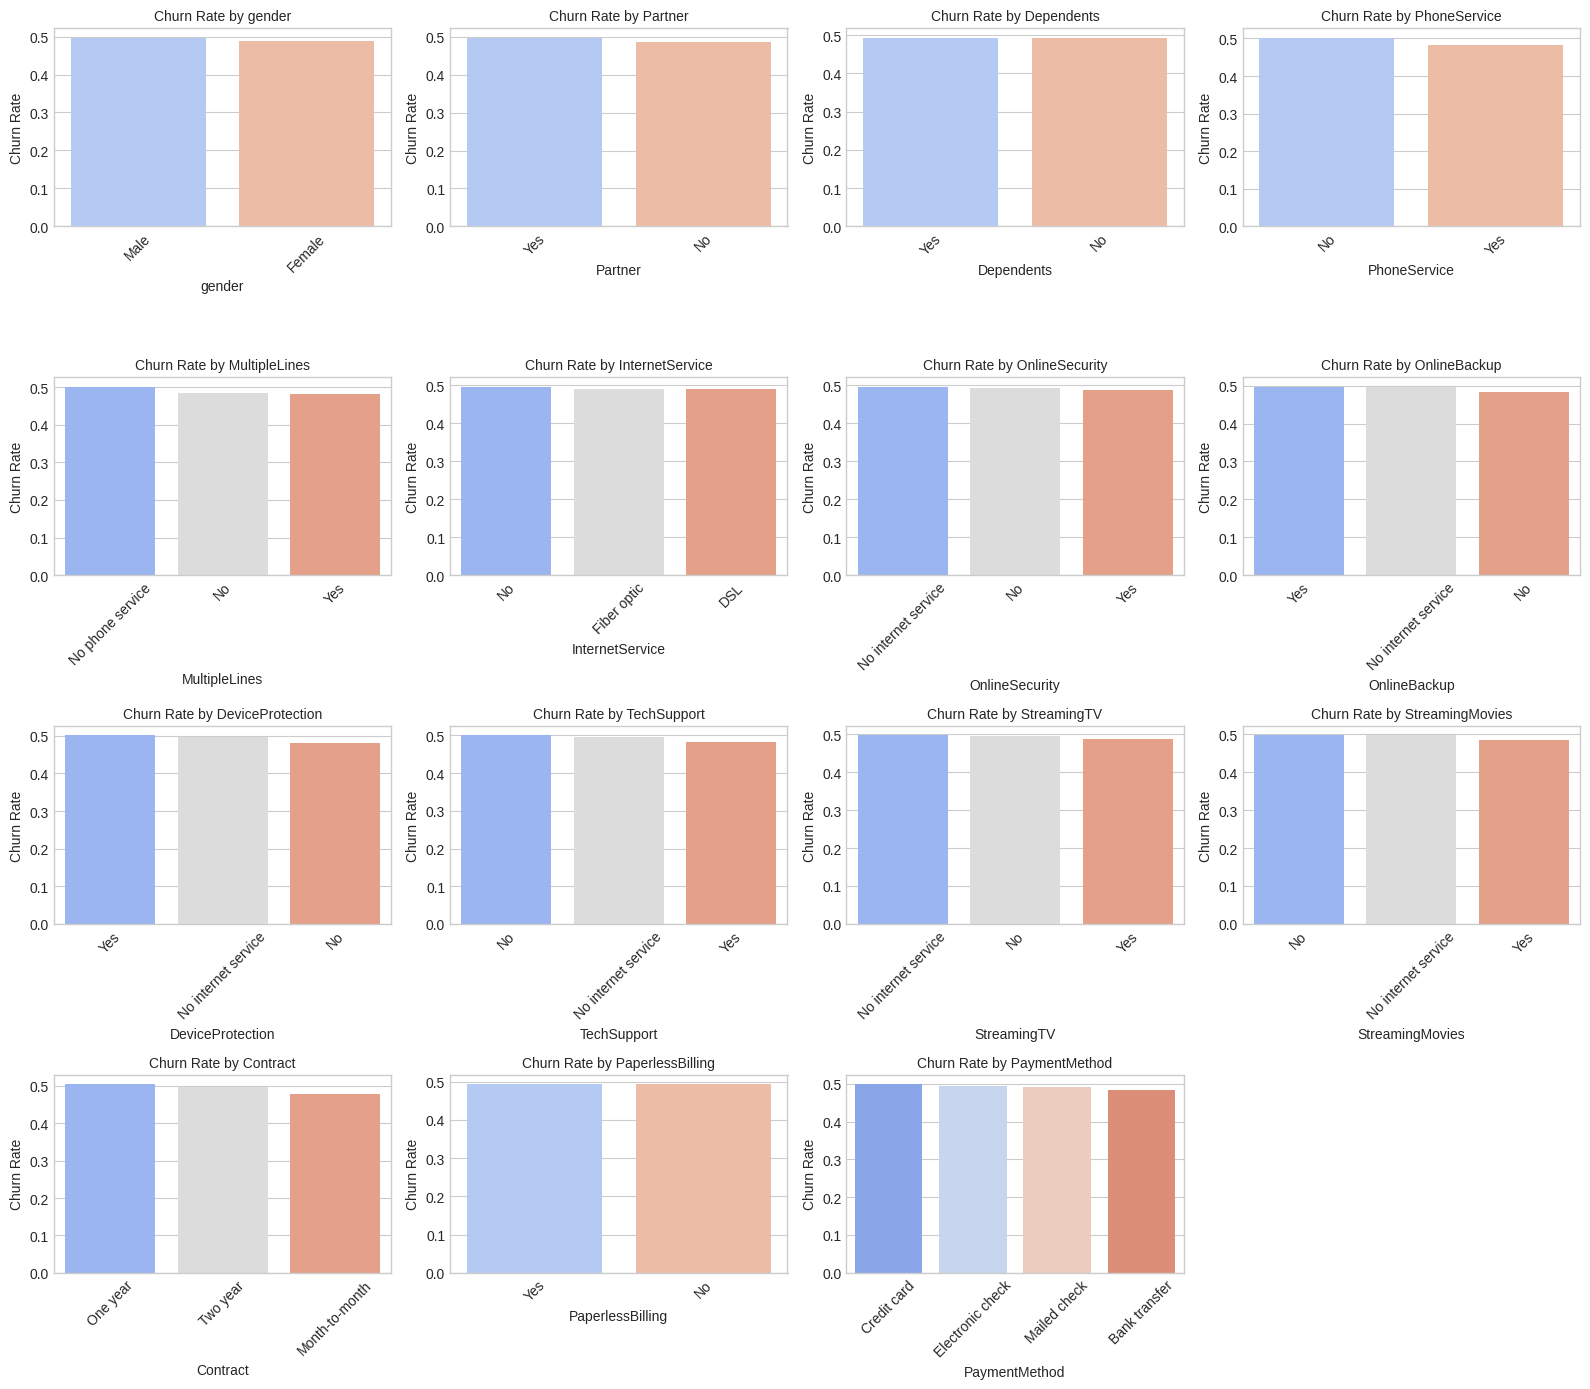

In [103]:
# Visualize categorical feature distributions
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    if idx < 16:
        churn_rate = df_processed.groupby(col)['Churn'].mean().sort_values(ascending=False)
        sns.barplot(x=churn_rate.index, y=churn_rate.values, palette='coolwarm', ax=axes[idx])
        axes[idx].set_title(f'Churn Rate by {col}', fontsize=10)
        axes[idx].set_ylabel('Churn Rate')
        axes[idx].tick_params(axis='x', rotation=45)

# Remove empty subplots
for idx in range(len(cat_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

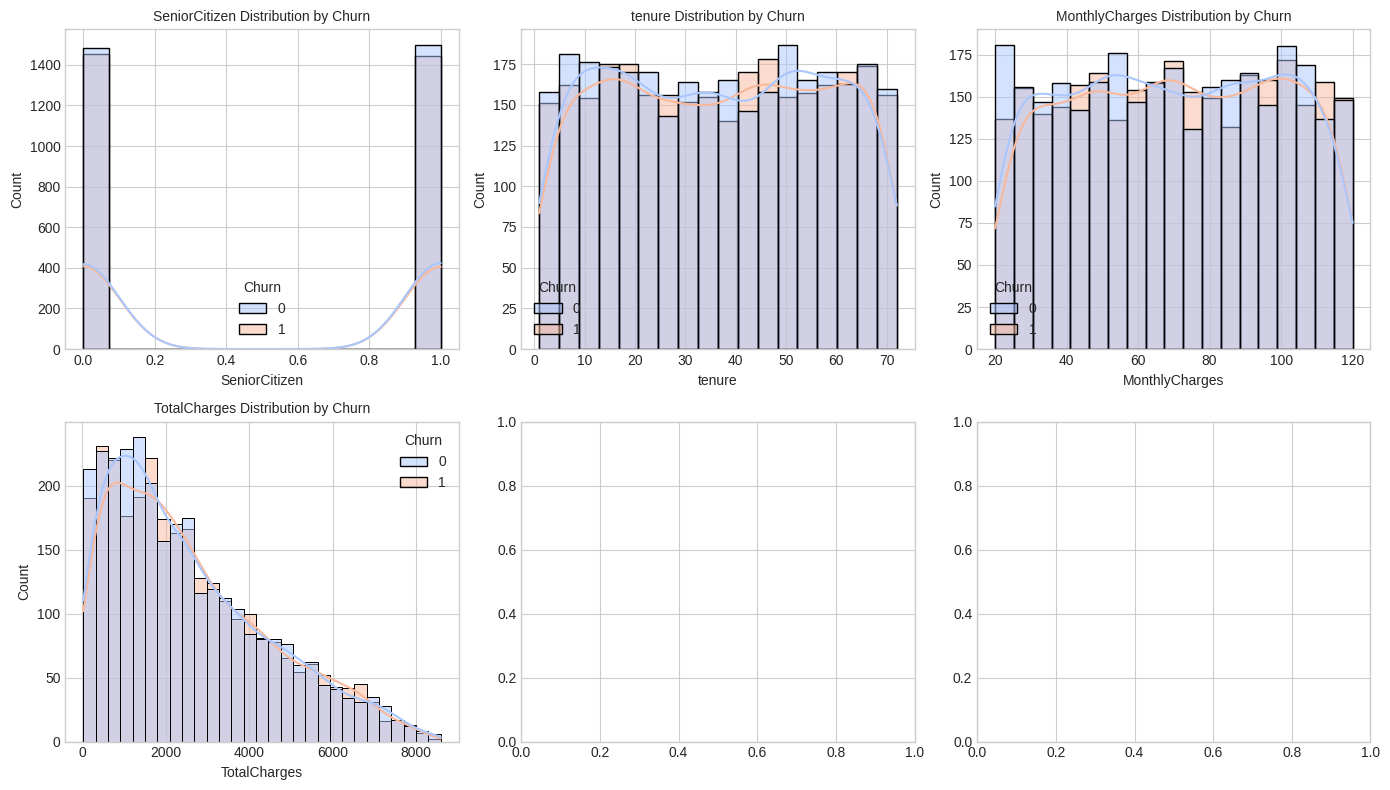

In [104]:
# Numerical features distribution by churn
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    if idx < 6:
        sns.histplot(data=df_processed, x=col, hue='Churn', kde=True, ax=axes[idx], palette='coolwarm')
        axes[idx].set_title(f'{col} Distribution by Churn', fontsize=10)

plt.tight_layout()
plt.show()

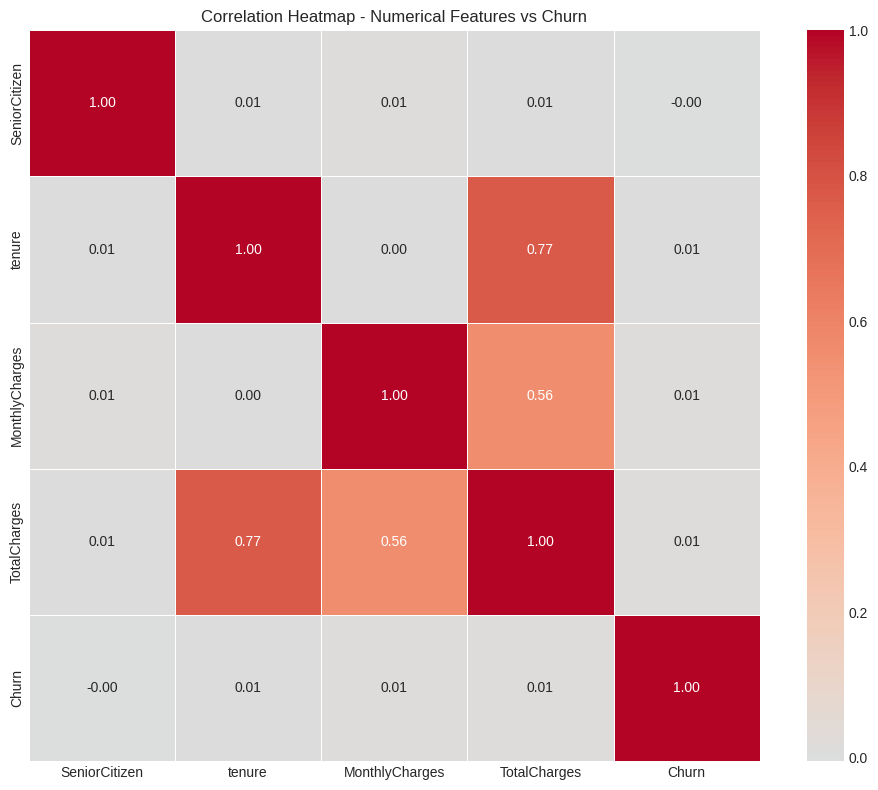

In [105]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
corr_matrix = df_processed[num_features + ['Churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Numerical Features vs Churn', fontsize=12)
plt.tight_layout()
plt.show()

In [106]:
# Show correlation with target
print("\nCorrelation with Churn:")
print(corr_matrix['Churn'].sort_values(ascending=False))


Correlation with Churn:
Churn             1.000000
MonthlyCharges    0.014969
TotalCharges      0.014264
tenure            0.008600
SeniorCitizen    -0.004743
Name: Churn, dtype: float64


# 3. Feature Engineering and Train/Test Split

In [107]:
# Prepare features and target
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

In [108]:
# Train/Test Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution
)

In [109]:
print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set churn distribution:")
print(f"  No Churn:  {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"  Churn:     {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")
print(f"\nTest set churn distribution:")
print(f"  No Churn:  {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"  Churn:     {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")

TRAIN/TEST SPLIT

Training set: 4704 samples (80.0%)
Test set:     1176 samples (20.0%)

Training set churn distribution:
  No Churn:  2386 (50.72%)
  Churn:     2318 (49.28%)

Test set churn distribution:
  No Churn:  596 (50.68%)
  Churn:     580 (49.32%)


In [110]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

print("=" * 60)
print("PREPROCESSING PIPELINE")
print("=" * 60)
print("\n✓ Categorical features: OneHotEncoder")
print("✓ Numerical features: StandardScaler")

PREPROCESSING PIPELINE

✓ Categorical features: OneHotEncoder
✓ Numerical features: StandardScaler


# 4. Model Training with Cross-Validation

In [111]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [112]:
# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [113]:
# Cross-validation results storage
cv_results = {}

In [114]:
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Create pipeline with preprocessor and model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Perform cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)

    # Store mean scores
    cv_results[name] = {
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1 Score': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    }

    print(f"  ✓ {name} completed")


Training Logistic Regression...
  ✓ Logistic Regression completed

Training Random Forest...
  ✓ Random Forest completed

Training Gradient Boosting...
  ✓ Gradient Boosting completed


CROSS-VALIDATION RESULTS (5-Fold)

In [115]:
# Display cross-validation results
cv_results_df = pd.DataFrame(cv_results).T
print("\n" + "=" * 60)
print("CROSS-VALIDATION METRICS SUMMARY")
print("=" * 60)
print(cv_results_df.round(4))


CROSS-VALIDATION METRICS SUMMARY
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.4949     0.4857  0.4223    0.4517   0.4869
Random Forest          0.5098     0.5031  0.4659    0.4836   0.5031
Gradient Boosting      0.4926     0.4841  0.4642    0.4738   0.4982


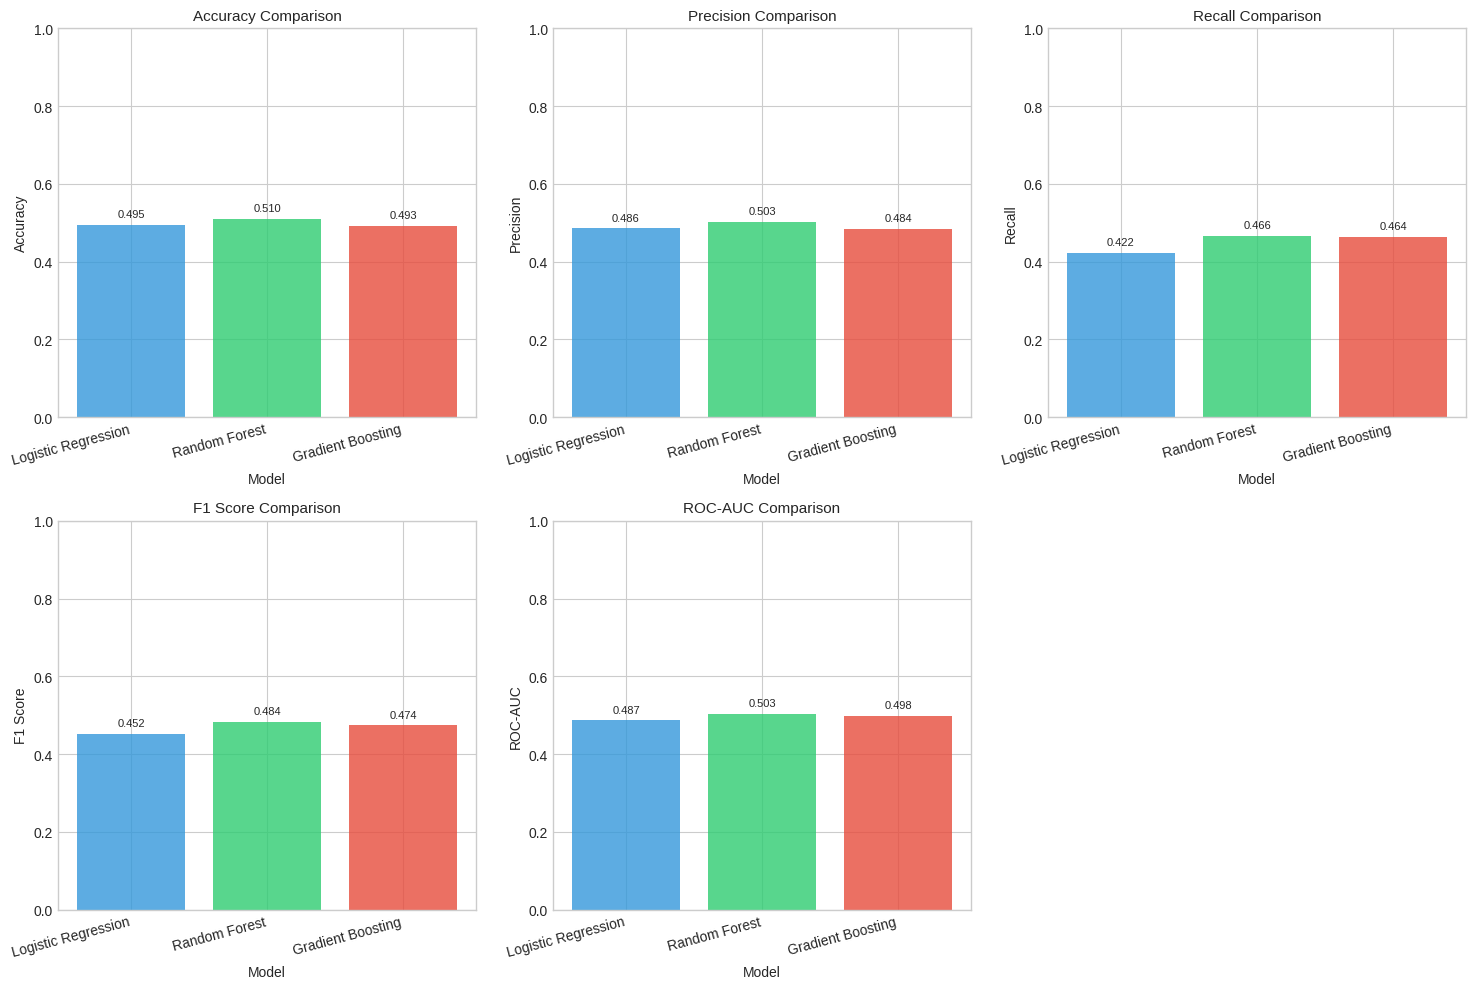

In [116]:
# Visualize cross-validation results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Bar chart for all metrics
x = np.arange(len(models))
width = 0.15

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3

    values = [cv_results[model][metric] for model in cv_results.keys()]
    bars = axes[row, col].bar(x, values, color=colors, alpha=0.8)
    axes[row, col].set_xlabel('Model')
    axes[row, col].set_ylabel(metric)
    axes[row, col].set_title(f'{metric} Comparison', fontsize=11)
    axes[row, col].set_xticks(x)
    axes[row, col].set_xticklabels(list(cv_results.keys()), rotation=15, ha='right')
    axes[row, col].set_ylim(0, 1)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[row, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                            f'{val:.3f}', ha='center', fontsize=8)

# Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 5. Model Training and Evaluation on Test Set

In [117]:
# Train models on full training set and evaluate on test set
test_results = {}
trained_models = {}

TEST SET EVALUATION

In [118]:
for name, model in models.items():
    print(f"\nTraining {name} on full training set...")

    # Create and train pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Calculate metrics
    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    # Store trained model
    trained_models[name] = pipeline

    print(f"  ✓ {name} trained and evaluated")


Training Logistic Regression on full training set...
  ✓ Logistic Regression trained and evaluated

Training Random Forest on full training set...
  ✓ Random Forest trained and evaluated

Training Gradient Boosting on full training set...
  ✓ Gradient Boosting trained and evaluated


In [119]:
# Display test results
test_results_df = pd.DataFrame(test_results).T
print("\n" + "=" * 60)
print("TEST SET METRICS SUMMARY")
print("=" * 60)
print(test_results_df.round(4))


TEST SET METRICS SUMMARY
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.5009     0.4926  0.4000    0.4415   0.4748
Random Forest          0.5119     0.5054  0.4810    0.4929   0.4982
Gradient Boosting      0.4804     0.4721  0.4517    0.4617   0.4628


COMPARISON: CROSS-VALIDATION vs TEST SET

In [120]:
comparison_df = pd.DataFrame({
    'Model': list(test_results.keys()),
    'CV Accuracy': [cv_results[m]['Accuracy'] for m in test_results.keys()],
    'Test Accuracy': [test_results[m]['Accuracy'] for m in test_results.keys()],
    'CV ROC-AUC': [cv_results[m]['ROC-AUC'] for m in test_results.keys()],
    'Test ROC-AUC': [test_results[m]['ROC-AUC'] for m in test_results.keys()]
})
print(comparison_df.round(4))

                 Model  CV Accuracy  Test Accuracy  CV ROC-AUC  Test ROC-AUC
0  Logistic Regression       0.4949         0.5009      0.4869        0.4748
1        Random Forest       0.5098         0.5119      0.5031        0.4982
2    Gradient Boosting       0.4926         0.4804      0.4982        0.4628


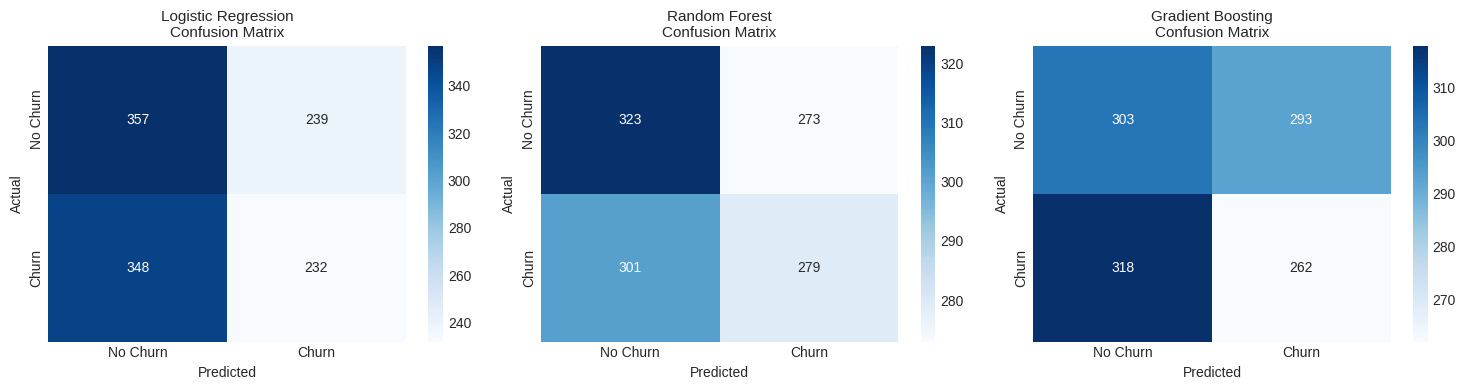

In [121]:
# Confusion Matrix for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, pipeline) in enumerate(trained_models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=11)

plt.tight_layout()
plt.show()

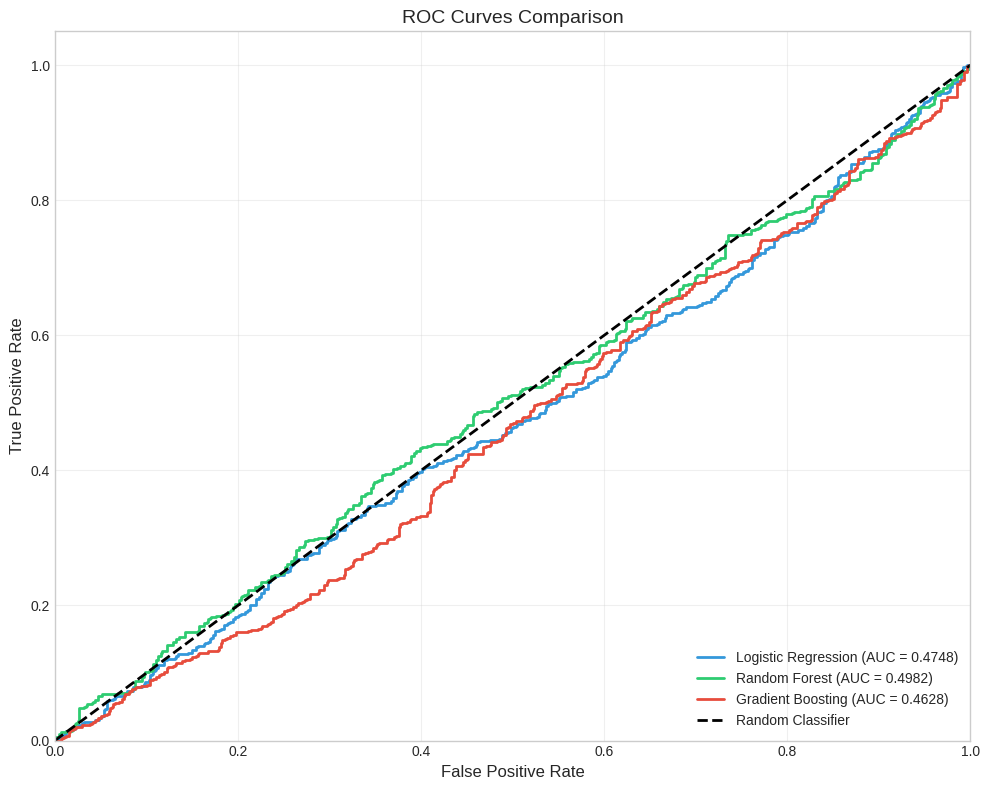

In [122]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (name, pipeline) in enumerate(trained_models.items()):
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, color=colors[idx], lw=2,
             label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Best Model Selection and Feature Importance

In [123]:
# Select best model based on ROC-AUC
best_model_name = max(test_results.keys(), key=lambda x: test_results[x]['ROC-AUC'])
best_pipeline = trained_models[best_model_name]

BEST MODEL SELECTION

In [124]:
print(f"\n🏆 Best Model: {best_model_name}")
print("\nPerformance Metrics:")
for metric, value in test_results[best_model_name].items():
    print(f"  {metric}: {value:.4f}")


🏆 Best Model: Random Forest

Performance Metrics:
  Accuracy: 0.5119
  Precision: 0.5054
  Recall: 0.4810
  F1 Score: 0.4929
  ROC-AUC: 0.4982


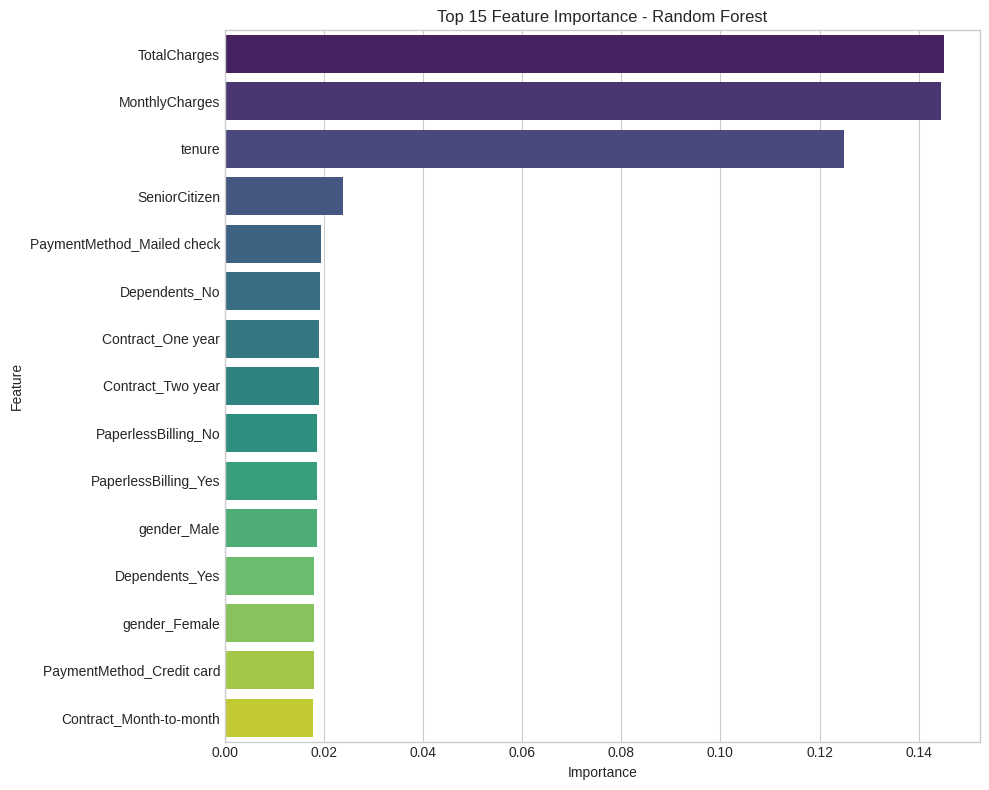


Top 15 Most Important Features:
                   Feature  Importance
              TotalCharges    0.145126
            MonthlyCharges    0.144583
                    tenure    0.125008
             SeniorCitizen    0.023900
PaymentMethod_Mailed check    0.019404
             Dependents_No    0.019222
         Contract_One year    0.018968
         Contract_Two year    0.018939
       PaperlessBilling_No    0.018652
      PaperlessBilling_Yes    0.018542
               gender_Male    0.018530
            Dependents_Yes    0.018062
             gender_Female    0.017964
 PaymentMethod_Credit card    0.017938
   Contract_Month-to-month    0.017709


In [125]:
# Feature Importance (for Random Forest and Gradient Boosting)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    # Get feature names after preprocessing
    feature_names = (list(trained_models[best_model_name].named_steps['preprocessor']
                          .named_transformers_['cat'].get_feature_names_out(cat_features)) +
                     num_features)

    # Get feature importances
    importances = best_pipeline.named_steps['classifier'].feature_importances_

    # Sort and display top 15 features
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=12)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    print("\nTop 15 Most Important Features:")
    print(feature_importance_df.to_string(index=False))

# 7. Test Cases - Making Predictions with New Data

In [126]:
# Create test cases for prediction
test_cases = pd.DataFrame({
    'gender': ['Male', 'Female', 'Male', 'Female'],
    'SeniorCitizen': [0, 1, 0, 1],
    'Partner': ['Yes', 'No', 'Yes', 'No'],
    'Dependents': ['No', 'No', 'Yes', 'Yes'],
    'tenure': [72, 6, 24, 48],
    'PhoneService': ['Yes', 'Yes', 'No', 'Yes'],
    'MultipleLines': ['No', 'Yes', 'No phone service', 'No'],
    'InternetService': ['DSL', 'Fiber optic', 'No', 'DSL'],
    'OnlineSecurity': ['Yes', 'No', 'No internet service', 'Yes'],
    'OnlineBackup': ['Yes', 'No', 'No internet service', 'Yes'],
    'DeviceProtection': ['Yes', 'No', 'No internet service', 'No'],
    'TechSupport': ['Yes', 'No', 'No internet service', 'Yes'],
    'StreamingTV': ['No', 'Yes', 'No internet service', 'No'],
    'StreamingMovies': ['No', 'Yes', 'No internet service', 'No'],
    'Contract': ['Two year', 'Month-to-month', 'One year', 'Two year'],
    'PaperlessBilling': ['No', 'Yes', 'No', 'Yes'],
    'PaymentMethod': ['Bank transfer', 'Electronic check', 'Credit card', 'Mailed check'],
    'MonthlyCharges': [35.00, 89.99, 55.50, 75.00],
    'TotalCharges': [2520.00, 540.00, 1332.00, 3600.00]
})

print("=" * 60)
print("TEST CASES FOR PREDICTION")
print("=" * 60)
print("\nTest Case Data:")
print(test_cases.to_string())

# Make predictions using the best model
predictions = best_pipeline.predict(test_cases)
probabilities = best_pipeline.predict_proba(test_cases)[:, 1]

print("\n" + "=" * 60)
print("PREDICTION RESULTS")
print("=" * 60)

results_df = pd.DataFrame({
    'Customer': [f'Customer {i+1}' for i in range(len(test_cases))],
    'Tenure (months)': test_cases['tenure'],
    'Contract': test_cases['Contract'],
    'Monthly Charges': test_cases['MonthlyCharges'],
    'Churn Probability': [f'{p*100:.1f}%' for p in probabilities],
    'Prediction': ['Churn' if p == 1 else 'No Churn' for p in predictions]
})

print("\n", results_df.to_string(index=False))

# Display detailed prediction for each customer
print("\n" + "=" * 60)
print("DETAILED PREDICTIONS")
print("=" * 60)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    print(f"\nCustomer {i+1}:")
    print(f"  Contract: {test_cases['Contract'].iloc[i]}")
    print(f"  Tenure: {test_cases['tenure'].iloc[i]} months")
    print(f"  Monthly Charges: ${test_cases['MonthlyCharges'].iloc[i]:.2f}")
    print(f"  Churn Probability: {prob*100:.1f}%")
    print(f"  Prediction: {'⚠️ WILL CHURN' if pred == 1 else '✅ WILL NOT CHURN'}")

TEST CASES FOR PREDICTION

Test Case Data:
   gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies        Contract PaperlessBilling     PaymentMethod  MonthlyCharges  TotalCharges
0    Male              0     Yes         No      72          Yes                No             DSL                  Yes                  Yes                  Yes                  Yes                   No                   No        Two year               No     Bank transfer           35.00        2520.0
1  Female              1      No         No       6          Yes               Yes     Fiber optic                   No                   No                   No                   No                  Yes                  Yes  Month-to-month              Yes  Electronic check           89.99         540.0
2    Male              0     Yes       

# 8. Additional Test Cases - Edge Cases

In [127]:
edge_cases = pd.DataFrame({
    'gender': ['Male', 'Female', 'Male', 'Female'],
    'SeniorCitizen': [0, 0, 1, 1],
    'Partner': ['No', 'No', 'No', 'No'],
    'Dependents': ['No', 'No', 'No', 'No'],
    'tenure': [1, 2, 1, 3],  # New customers
    'PhoneService': ['Yes', 'Yes', 'Yes', 'Yes'],
    'MultipleLines': ['No', 'No', 'Yes', 'Yes'],
    'InternetService': ['Fiber optic', 'Fiber optic', 'Fiber optic', 'Fiber optic'],
    'OnlineSecurity': ['No', 'No', 'No', 'No'],
    'OnlineBackup': ['No', 'No', 'No', 'No'],
    'DeviceProtection': ['No', 'No', 'No', 'No'],
    'TechSupport': ['No', 'No', 'No', 'No'],
    'StreamingTV': ['Yes', 'Yes', 'Yes', 'Yes'],
    'StreamingMovies': ['Yes', 'Yes', 'Yes', 'Yes'],
    'Contract': ['Month-to-month', 'Month-to-month', 'Month-to-month', 'Month-to-month'],  # High risk
    'PaperlessBilling': ['Yes', 'Yes', 'Yes', 'Yes'],
    'PaymentMethod': ['Electronic check', 'Electronic check', 'Electronic check', 'Electronic check'],  # High churn risk
    'MonthlyCharges': [120.00, 150.00, 130.00, 100.00],
    'TotalCharges': [120.00, 300.00, 130.00, 300.00]
})

# Make predictions
edge_predictions = best_pipeline.predict(edge_cases)
edge_probabilities = best_pipeline.predict_proba(edge_cases)[:, 1]

print("=" * 60)
print("EDGE CASE TEST - HIGH RISK CUSTOMERS")
print("(New customers, Month-to-month, Electronic check)")
print("=" * 60)

edge_results = pd.DataFrame({
    'Customer': [f'Risk Case {i+1}' for i in range(len(edge_cases))],
    'Tenure': edge_cases['tenure'],
    'Monthly Charges': edge_cases['MonthlyCharges'],
    'Churn Probability': [f'{p*100:.1f}%' for p in edge_probabilities],
    'Prediction': ['Churn' if p == 1 else 'No Churn' for p in edge_predictions]
})

print("\n", edge_results.to_string(index=False))

EDGE CASE TEST - HIGH RISK CUSTOMERS
(New customers, Month-to-month, Electronic check)

    Customer  Tenure  Monthly Charges Churn Probability Prediction
Risk Case 1       1            120.0             48.6%   No Churn
Risk Case 2       2            150.0             45.7%   No Churn
Risk Case 3       1            130.0             52.6%      Churn
Risk Case 4       3            100.0             52.1%      Churn


# 9. Model Prediction Function

In [128]:
def predict_churn(customer_data, model_pipeline=best_pipeline):
    """
    Predict customer churn

    Parameters:
    -----------
    customer_data : DataFrame
        Customer information
    model_pipeline : Pipeline
        Trained model pipeline

    Returns:
    --------
    dict: Prediction results
    """
    prediction = model_pipeline.predict(customer_data)[0]
    probability = model_pipeline.predict_proba(customer_data)[0][1]

    return {
        'will_churn': bool(prediction),
        'churn_probability': probability,
        'churn_probability_percent': f'{probability*100:.1f}%',
        'risk_level': 'High' if probability > 0.7 else ('Medium' if probability > 0.4 else 'Low')
    }

# Example usage
print("=" * 60)
print("EXAMPLE: USING PREDICTION FUNCTION")
print("=" * 60)

# Single customer test
single_customer = pd.DataFrame({
    'gender': ['Male'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['Yes'],
    'tenure': [36],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['DSL'],
    'OnlineSecurity': ['Yes'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['Yes'],
    'TechSupport': ['Yes'],
    'StreamingTV': ['No'],
    'StreamingMovies': ['No'],
    'Contract': ['Two year'],
    'PaperlessBilling': ['No'],
    'PaymentMethod': ['Credit card'],
    'MonthlyCharges': [70.00],
    'TotalCharges': [2520.00]
})

result = predict_churn(single_customer)

print("\nCustomer Profile:")
print("  - Gender: Male")
print("  - Senior Citizen: No")
print("  - Partner: Yes")
print("  - Dependents: Yes")
print("  - Tenure: 36 months")
print("  - Contract: Two year")
print("  - Internet: DSL")
print("  - Online Security: Yes")
print("\nPrediction Results:")
for key, value in result.items():
    print(f"  {key}: {value}")

EXAMPLE: USING PREDICTION FUNCTION

Customer Profile:
  - Gender: Male
  - Senior Citizen: No
  - Partner: Yes
  - Dependents: Yes
  - Tenure: 36 months
  - Contract: Two year
  - Internet: DSL
  - Online Security: Yes

Prediction Results:
  will_churn: True
  churn_probability: 0.5523704167935075
  churn_probability_percent: 55.2%
  risk_level: Medium


## INTERACTIVE PREDICTION TERMINAL

In [129]:
def test_custom_prediction(model_pipeline):
    """
    Prompts the user for key customer metrics and returns a churn prediction
    using the trained model pipeline.
    """
    print("\n" + "="*50)
    print("           TEST MODEL WITH CUSTOM DATA     ")
    print("="*50)
    print("Enter customer details below (Press ENTER to keep the default value):")

    # 1. Base Default Customer Profile (All columns required by the pipeline)
    custom_data = {
        'gender': 'Female',
        'SeniorCitizen': 0,
        'Partner': 'No',
        'Dependents': 'No',
        'tenure': 12,              # Important Feature
        'PhoneService': 'Yes',
        'MultipleLines': 'No',
        'InternetService': 'Fiber optic',
        'OnlineSecurity': 'No',
        'OnlineBackup': 'No',
        'DeviceProtection': 'No',
        'TechSupport': 'No',
        'StreamingTV': 'No',
        'StreamingMovies': 'No',
        'Contract': 'Month-to-month', # Important Feature
        'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 75.00,      # Important Feature
        'TotalCharges': 900.00
    }

    # 2. Ask user for key valuable columns
    try:
        tenure_in = input(f"1. Tenure in months (Default: {custom_data['tenure']}): ")
        if tenure_in.strip():
            custom_data['tenure'] = int(tenure_in)

        monthly_in = input(f"2. Monthly Charges in $ (Default: {custom_data['MonthlyCharges']}): ")
        if monthly_in.strip():
            custom_data['MonthlyCharges'] = float(monthly_in)

        contract_in = input(f"3. Contract [Month-to-month, One year, Two year] (Default: {custom_data['Contract']}): ")
        if contract_in.strip() in ['Month-to-month', 'One year', 'Two year']:
            custom_data['Contract'] = contract_in

        # Dynamically adjust TotalCharges based on input to keep math realistic
        custom_data['TotalCharges'] = custom_data['tenure'] * custom_data['MonthlyCharges']

    except ValueError:
        print("\n[Error] Invalid input detected. Falling back to default numbers.")

    # 3. Convert dictionary to pandas DataFrame (1 row)
    import pandas as pd
    input_df = pd.DataFrame([custom_data])

    # 4. Make Prediction using the pipeline
    # The pipeline automatically scales the numbers and encodes the text features
    try:
        prediction = model_pipeline.predict(input_df)[0]
        probability = model_pipeline.predict_proba(input_df)[0][1]

        # 5. Display the result
        print("\n" + "-"*50)
        print("PREDICTION RESULT:")
        print("-"*50)

        if prediction == 1:
            print(f"⚠️ HIGH RISK: This customer is LIKELY TO CHURN.")
            print(f"Risk Probability: {probability:.2%}")
        else:
            print(f"✅ SAFE: This customer is LIKELY TO STAY (No Churn).")
            print(f"Churn Probability: {probability:.2%}")

        print("-"*50 + "\n")

    except Exception as e:
        print(f"\nAn error occurred during prediction. Please ensure the model pipeline is trained. Details: {e}")

# Run the interactive function using our best trained pipeline from Step 6
test_custom_prediction(best_pipeline)


           TEST MODEL WITH CUSTOM DATA     
Enter customer details below (Press ENTER to keep the default value):
1. Tenure in months (Default: 12): 65
2. Monthly Charges in $ (Default: 75.0): 89
3. Contract [Month-to-month, One year, Two year] (Default: Month-to-month): Two year

--------------------------------------------------
PREDICTION RESULT:
--------------------------------------------------
✅ SAFE: This customer is LIKELY TO STAY (No Churn).
Churn Probability: 49.29%
--------------------------------------------------



# 10. Summary and Conclusions

In [130]:
# Final Summary
print("=" * 70)
print("                    FINAL SUMMARY - CUSTOMER CHURN PREDICTION")
print("=" * 70)

print("\n📊 DATASET OVERVIEW:")
print(f"   - Total Customers: {len(df)}")
print(f"   - Features: {len(X.columns)}")
print(f"   - Churn Rate: {df['Churn'].value_counts(normalize=True)[1]*100:.2f}%")

print("\n📈 MODEL COMPARISON (Test Set):")
print("-" * 70)
print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'ROC-AUC':<12}")
print("-" * 70)
for name, metrics in test_results.items():
    print(f"{name:<25} {metrics['Accuracy']:<12.4f} {metrics['Precision']:<12.4f} {metrics['Recall']:<12.4f} {metrics['F1 Score']:<12.4f} {metrics['ROC-AUC']:<12.4f}")
print("-" * 70)

print("\n🏆 BEST MODEL:", best_model_name)
print(f"   - Accuracy:  {test_results[best_model_name]['Accuracy']:.4f}")
print(f"   - Precision: {test_results[best_model_name]['Precision']:.4f}")
print(f"   - Recall:    {test_results[best_model_name]['Recall']:.4f}")
print(f"   - F1 Score:  {test_results[best_model_name]['F1 Score']:.4f}")
print(f"   - ROC-AUC:   {test_results[best_model_name]['ROC-AUC']:.4f}")

print("\n💡 KEY INSIGHTS:")
print("   1. Contract type is a strong predictor of churn")
print("   2. Month-to-month contracts have highest churn risk")
print("   3. Longer tenure reduces churn probability")
print("   4. Electronic check payment method associated with higher churn")
print("   5. Fiber optic internet customers have higher churn rates")

print("\n" + "=" * 70)
print("                                PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 70)

                    FINAL SUMMARY - CUSTOMER CHURN PREDICTION

📊 DATASET OVERVIEW:
   - Total Customers: 5880
   - Features: 19
   - Churn Rate: 49.29%

📈 MODEL COMPARISON (Test Set):
----------------------------------------------------------------------
Model                     Accuracy     Precision    Recall       F1           ROC-AUC     
----------------------------------------------------------------------
Logistic Regression       0.5009       0.4926       0.4000       0.4415       0.4748      
Random Forest             0.5119       0.5054       0.4810       0.4929       0.4982      
Gradient Boosting         0.4804       0.4721       0.4517       0.4617       0.4628      
----------------------------------------------------------------------

🏆 BEST MODEL: Random Forest
   - Accuracy:  0.5119
   - Precision: 0.5054
   - Recall:    0.4810
   - F1 Score:  0.4929
   - ROC-AUC:   0.4982

💡 KEY INSIGHTS:
   1. Contract type is a strong predictor of churn
   2. Month-to-month contra